# TGUAI — Анализ Output Manipulation

Сравнение трёх стратегий промптинга для сегментации книжных отзывов:
- **baseline** — свободный промпт (без ограничений на формат)
- **structured** — JSON-схема + whitelist меток + Guardrails
- **few_shot** — 2 реальных примера + строгая схема

Данные: 10 отзывов × 3 стратегии = 30 запросов к LLM API.

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

plt.rcParams['figure.figsize'] = (12, 5)
plt.style.use('seaborn-v0_8-whitegrid')

# Загружаем сохранённые результаты
with open('results.json', encoding='utf-8') as f:
    data = json.load(f)

results = data['results']
summary = data['summary']
df = pd.DataFrame(results)

print(f'Загружено записей: {len(df)}')
print(f'Стратегии: {list(df["strategy"].unique())}')
df[['strategy', 'success', 'n_spans', 'n_errors', 'n_fixed', 'elapsed_sec']].head(6)

Загружено записей: 30
Стратегии: ['baseline', 'structured', 'few_shot']


,strategy,success,n_spans,n_errors,n_fixed,elapsed_sec
0,baseline,False,0,1,0,12.95
1,structured,True,5,0,0,9.20
2,few_shot,True,4,0,0,6.49
3,baseline,False,0,1,0,11.81
4,structured,True,7,0,0,14.65
5,few_shot,True,2,0,0,7.59


## 1. Успешность парсинга, среднее число спанов, время ответа

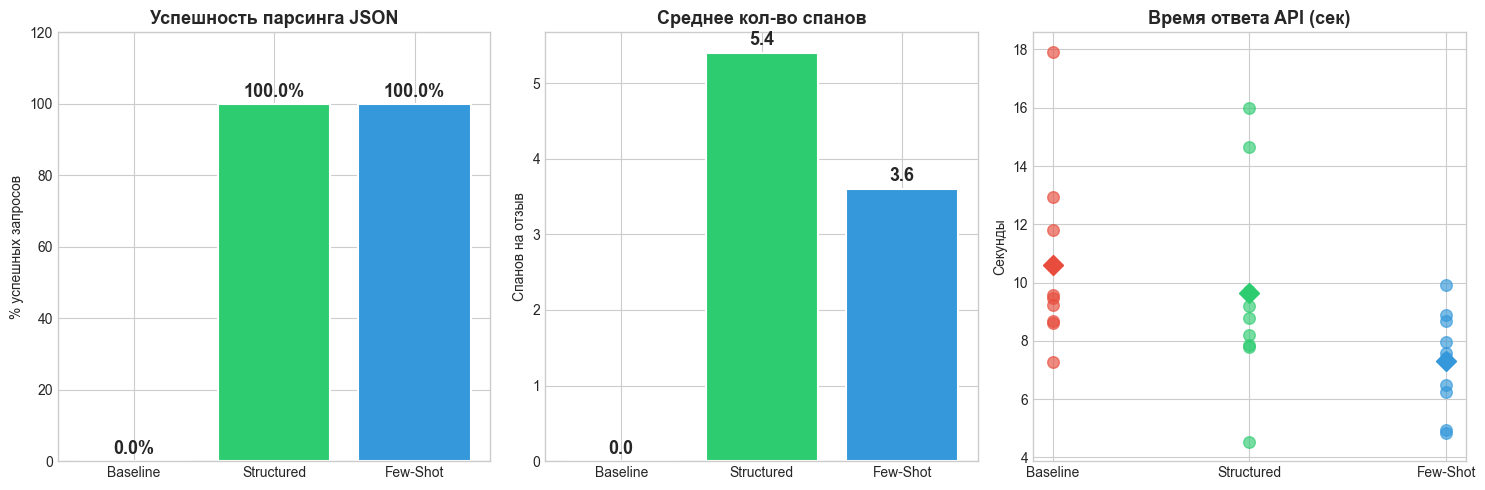

Сохранено: results_overview.png


In [2]:
strategies   = ['baseline', 'structured', 'few_shot']
colors       = ['#e74c3c', '#2ecc71', '#3498db']
labels_ru    = ['Baseline', 'Structured', 'Few-Shot']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# --- 1: Success rate ---
success_rates = [summary[s]['success_rate'] for s in strategies]
bars = axes[0].bar(labels_ru, success_rates, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_ylim(0, 120)
axes[0].set_title('Успешность парсинга JSON', fontsize=13, fontweight='bold')
axes[0].set_ylabel('% успешных запросов')
for bar, val in zip(bars, success_rates):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                 f'{val}%', ha='center', fontsize=13, fontweight='bold')

# --- 2: Avg spans ---
avg_spans = [summary[s]['avg_spans'] for s in strategies]
bars2 = axes[1].bar(labels_ru, avg_spans, color=colors, edgecolor='white', linewidth=1.5)
axes[1].set_title('Среднее кол-во спанов', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Спанов на отзыв')
for bar, val in zip(bars2, avg_spans):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f'{val}', ha='center', fontsize=13, fontweight='bold')

# --- 3: Response time scatter ---
for strat, color, label in zip(strategies, colors, labels_ru):
    times = df[df['strategy'] == strat]['elapsed_sec']
    axes[2].scatter([label]*len(times), times, color=color, alpha=0.65, s=70, zorder=3)
    axes[2].plot([label], [times.mean()], marker='D', color=color, markersize=10, zorder=4)
axes[2].set_title('Время ответа API (сек)', fontsize=13, fontweight='bold')
axes[2].set_ylabel('Секунды')

plt.tight_layout()
plt.savefig('results_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('Сохранено: results_overview.png')

## 2. Boxplot — разброс числа спанов

/var/folders/0k/x7t4h38x4qb41tg61shfwwk80000gn/T/ipykernel_18958/3013537024.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_strategy, labels=labels_ru, patch_artist=True,


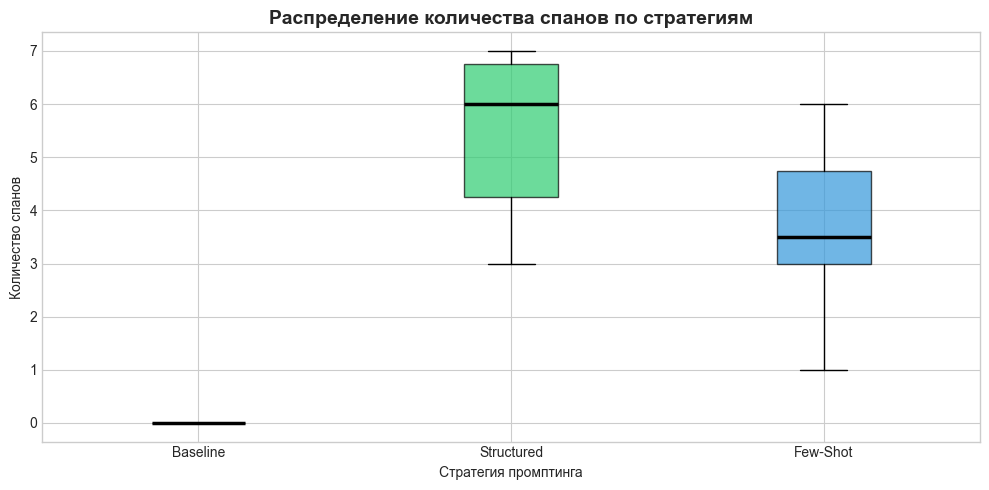

Сохранено: results_boxplot.png


In [3]:
fig, ax = plt.subplots(figsize=(10, 5))

data_by_strategy = [df[df['strategy'] == s]['n_spans'].tolist() for s in strategies]

bp = ax.boxplot(data_by_strategy, labels=labels_ru, patch_artist=True,
                medianprops=dict(color='black', linewidth=2.5))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_title('Распределение количества спанов по стратегиям', fontsize=14, fontweight='bold')
ax.set_ylabel('Количество спанов')
ax.set_xlabel('Стратегия промптинга')

plt.tight_layout()
plt.savefig('results_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Сохранено: results_boxplot.png')

## 3. Топ-10 меток (Structured vs Few-Shot)

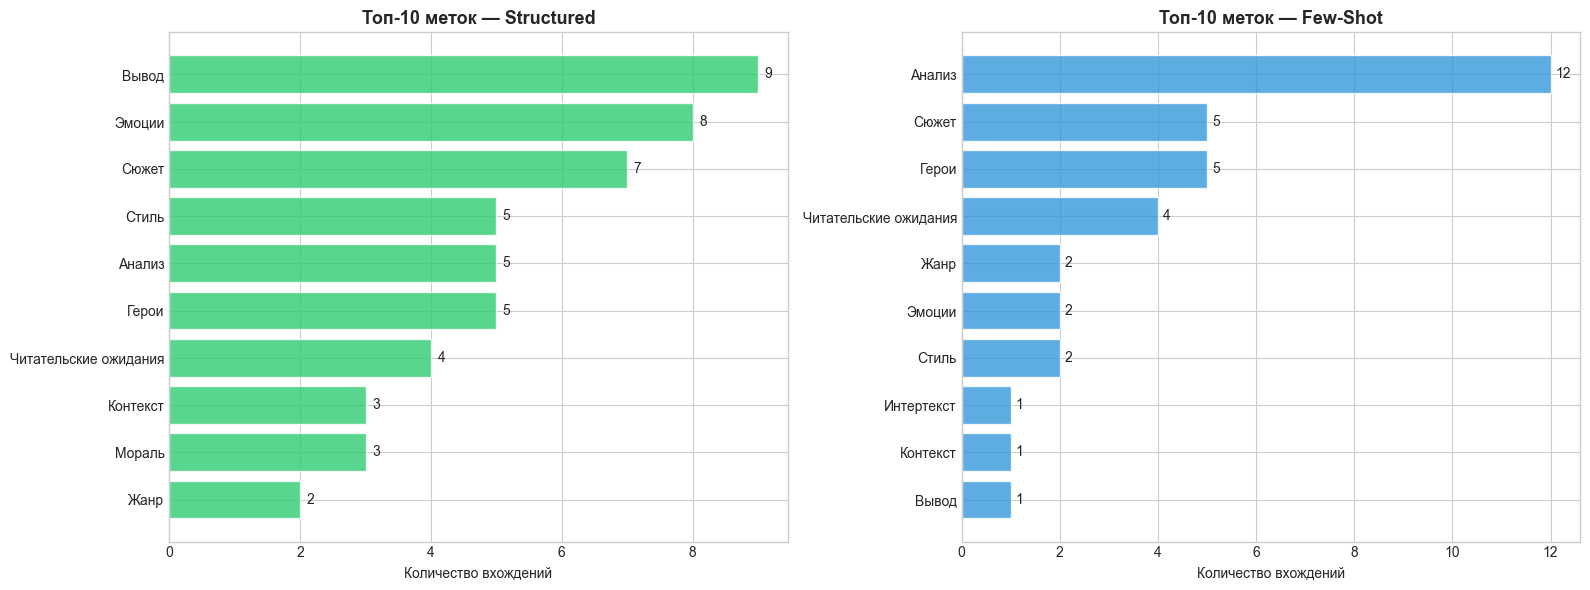

Сохранено: results_labels.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, strat, color, label in zip(
    axes, ['structured', 'few_shot'], ['#2ecc71', '#3498db'], ['Structured', 'Few-Shot']
):
    label_counts = Counter()
    for row in df[df['strategy'] == strat].itertuples():
        for span in row.validation['spans']:
            label_counts[span['label']] += 1

    top10 = label_counts.most_common(10)
    labels_list, counts = zip(*top10)

    bars = ax.barh(list(reversed(labels_list)), list(reversed(counts)),
                   color=color, alpha=0.8, edgecolor='white')
    ax.set_title(f'Топ-10 меток — {label}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Количество вхождений')
    for bar, val in zip(bars, list(reversed(counts))):
        ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                str(val), va='center', fontsize=10)

plt.tight_layout()
plt.savefig('results_labels.png', dpi=150, bbox_inches='tight')
plt.show()
print('Сохранено: results_labels.png')

## 4. Распределение Sentiment

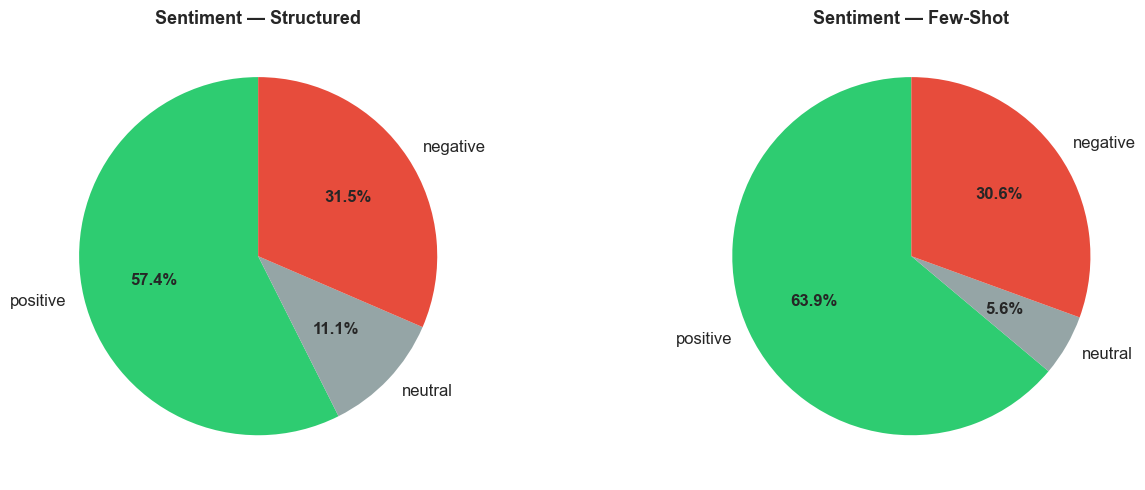

Сохранено: results_sentiment.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sentiment_colors = {'positive': '#2ecc71', 'negative': '#e74c3c', 'neutral': '#95a5a6'}

for ax, strat, label in zip(axes, ['structured', 'few_shot'], ['Structured', 'Few-Shot']):
    sent_counts = Counter()
    for row in df[df['strategy'] == strat].itertuples():
        for span in row.validation['spans']:
            sent_counts[span.get('sentiment', 'neutral')] += 1

    keys = list(sent_counts.keys())
    vals = list(sent_counts.values())
    clrs = [sentiment_colors.get(k, '#bdc3c7') for k in keys]

    wedges, texts, autotexts = ax.pie(
        vals, labels=keys, colors=clrs, autopct='%1.1f%%',
        startangle=90, textprops={'fontsize': 12}
    )
    for at in autotexts:
        at.set_fontweight('bold')
    ax.set_title(f'Sentiment — {label}', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('results_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()
print('Сохранено: results_sentiment.png')

## 5. Сводная таблица

In [6]:
rows = []
for strat in strategies:
    s = summary[strat]
    subset = df[df['strategy'] == strat]
    rows.append({
        'Стратегия':       strat,
        'Успех парсинга':  f"{s['success_rate']}%",
        'Спанов (avg)':    s['avg_spans'],
        'Ошибок (avg)':    s['avg_errors'],
        'Исправлено (avg)':s['avg_fixed'],
        'Время (avg, с)':  round(subset['elapsed_sec'].mean(), 2),
        'Запросов':        len(subset),
    })

pd.DataFrame(rows).set_index('Стратегия')

,Успех парсинга,Спанов (avg),Ошибок (avg),Исправлено (avg),"Время (avg, с)",Запросов
Стратегия,,,,,,
baseline,0.0%,0.0,1.0,0.0,10.61,10
structured,100.0%,5.4,0.1,0.1,9.64,10
few_shot,100.0%,3.6,0.0,0.0,7.30,10


## 6. Выводы

**Baseline** полностью непригоден для машинной обработки: успешность парсинга JSON — **0%**. Модель отвечает свободным текстом без гарантий формата.

**Structured** и **Few-Shot** дают **100% корректный JSON**. Guardrails не зафиксировали критических нарушений — whitelist меток и fuzzy matching работают.

**Few-Shot** выдаёт чуть меньше спанов — примеры из датасета содержат 2-3 спана и "калибруют" длину ответа.

**Практический вывод:** для промышленного применения достаточно стратегии `structured` — она не требует поддержки примеров, предсказуема и дешевле по токенам.